
# Kart Telemetry — End-to-End Workflow

Sync a wheel-cam Insta360 Go 3S (`.gyroflow`) to a MyChron logger (`.xrk`),
segment by lap, and produce per-lap telemetry.

This notebook is the whole pipeline in one place. It calls into the project
modules (`pipeline.sync_xrk`, `analysis.per_lap`) for tested core algorithms,
but every step is visible here with inline output.

**Sections**

1. [Setup](#1-setup) — imports, file paths
2. [Inputs](#2-inputs) — what's in the .gyroflow and the .xrk
3. [Synchronize](#3-synchronize) — cross-correlation finds the clock offset
4. [Verify sync visually](#4-verify-sync-visually) — overlay the two yaw signals
5. [Body-frame geometry](#5-body-frame-geometry) — column axis, gravity, tilt factor
6. [Lap detection](#6-lap-detection) — GPS return-to-start
7. [Per-lap plots](#7-per-lap-plots) — six laps, four panels each
8. [Summary table](#8-summary-table) — pandas DataFrame
9. [What we learned](#9-what-we-learned) — observations from this session


## 1. Setup

The two files we're analyzing. Change these paths to point at your own session
to re-run this on different data.

In [1]:
%matplotlib inline

import contextlib
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, correlate, sosfiltfilt

# Project modules (these are tested; we just call into them)
from pipeline.extract_imu import load_gyroflow
from pipeline.sync_xrk import (
    sync_imu_to_xrk,
    chassis_yaw_from_imu,
    chassis_yaw_from_xrk,
)
from analysis.per_lap import (
    detect_laps_from_gps,
    choose_lap_windows,
    extract_lap,
    plot_lap,
    lap_summary,
    steering_from_synced,
)

# === EDIT THESE for your session ===========================================
GYROFLOW = Path("/Users/henry/Desktop/PRO_VID_20260511_145850_00_060.gyroflow")
XRK      = Path("/Users/henry/Desktop/xrk/a_a_XTreme_a_0619.xrk")
# ===========================================================================


## 2. Inputs

Load both files and print metadata. The .gyroflow contains the raw IMU at
1 kHz (gyro + accel, in body frame). The .xrk has 32+ channels at varying
rates (GPS @ 25 Hz, RPM @ 20 Hz, etc).

In [2]:
# .gyroflow side
stream = load_gyroflow(GYROFLOW, source="wheel")
print(f"IMU stream:")
print(f"  samples:      {len(stream.t):,}")
print(f"  duration:     {stream.t[-1]:.1f} s")
print(f"  sample rate:  {stream.sample_rate_hz:.1f} Hz")
print(f"  orientation:  {stream.orientation}")
print()

# .xrk side — silence libxrk's cosmetic "Unknown units" warnings
import libxrk
with contextlib.redirect_stderr(io.StringIO()):
    log = libxrk.aim_xrk(str(XRK))

m = log.metadata
print(f"XRK log:")
print(f"  recording:    {m['Log Date']} {m['Log Time']}")
print(f"  driver:       {m['Driver']!r} @ track {m['Venue']!r}")
print(f"  logger model: {m['Logger Model ID']}, ID {m['Logger ID']}")
print(f"  duration:     {log.laps['end_time'][-1].as_py()/1000:.1f} s")
print(f"  channels:     {len(log.channels)}")
print(f"  XRK laps:     {log.laps.num_rows} (beacon-detected — often unreliable; see §6)")

IMU stream:
  samples:      519,179
  duration:     519.2 s
  sample rate:  1000.0 Hz
  orientation:  yXZ

Unknown units[8] for b'Distance Lap\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomY\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomZ\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
XRK log:
  recording:    05/11/2026 14:59:21
  driver:       'a' @ track 'XTreme'
  logger model: 787, ID 83056659
  duration:     290.0 s
  channels:     32
  XRK laps:     2 (beacon-detected — often unreliable; see §6)



## 3. Synchronize

Both streams measure chassis yaw during corners. Low-pass-filter the IMU's
column-axis projection to isolate the chassis component, cross-correlate
against the XRK's `GPS_Yaw_Rate` channel, and the peak gives the clock offset.

Trusting the device wall-clocks doesn't work — they drift independently by
tens of seconds. Cross-correlation gives the true offset.

In [3]:
sync = sync_imu_to_xrk(GYROFLOW, XRK)

print(f"  offset (add to IMU t):  {sync.offset_imu_to_xrk_s:+8.3f} s")
print(f"  peak |correlation|:     {sync.corr_peak:8.4f}   "
      f"({'STRONG' if sync.corr_peak > 0.5 else 'WEAK — check'})")
print(f"  sign:                   {sync.sign:+8d}   "
      f"({'as-is' if sync.sign == 1 else 'IMU flipped to match GPS convention'})")
print()
print(f"  column axis (body):     ({sync.column_axis[0]:+.3f}, "
      f"{sync.column_axis[1]:+.3f}, {sync.column_axis[2]:+.3f})")
print(f"  column tilt:            {sync.column_tilt_deg:.1f}° from world-vertical")
print(f"  tilt factor k:          {sync.column_tilt_factor:.4f}   "
      f"(= |column · world_up|, used to subtract chassis yaw downstream)")
print()
print(f"  gyro bias (deg/s):      ({np.rad2deg(sync.gyro_bias[0]):+.4f}, "
      f"{np.rad2deg(sync.gyro_bias[1]):+.4f}, {np.rad2deg(sync.gyro_bias[2]):+.4f})")

Unknown units[8] for b'Distance Lap\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomY\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomZ\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
  offset (add to IMU t):   -14.027 s
  peak |correlation|:       0.7835   (STRONG)
  sign:                         -1   (IMU flipped to match GPS convention)

  column axis (body):     (-0.315, +0.030, +0.949)
  column tilt:            40.6° from world-vertical
  tilt factor k:          0.7588   (= |column · world_up|, used to subtract chassis yaw downstream)

  gyro bias (deg/s):      (-0.1389, +0.0353, +0.0098)



## 4. Verify sync visually

Plot both yaw signals before and after sync. After alignment, both signals
should peak at the same moments through every corner.

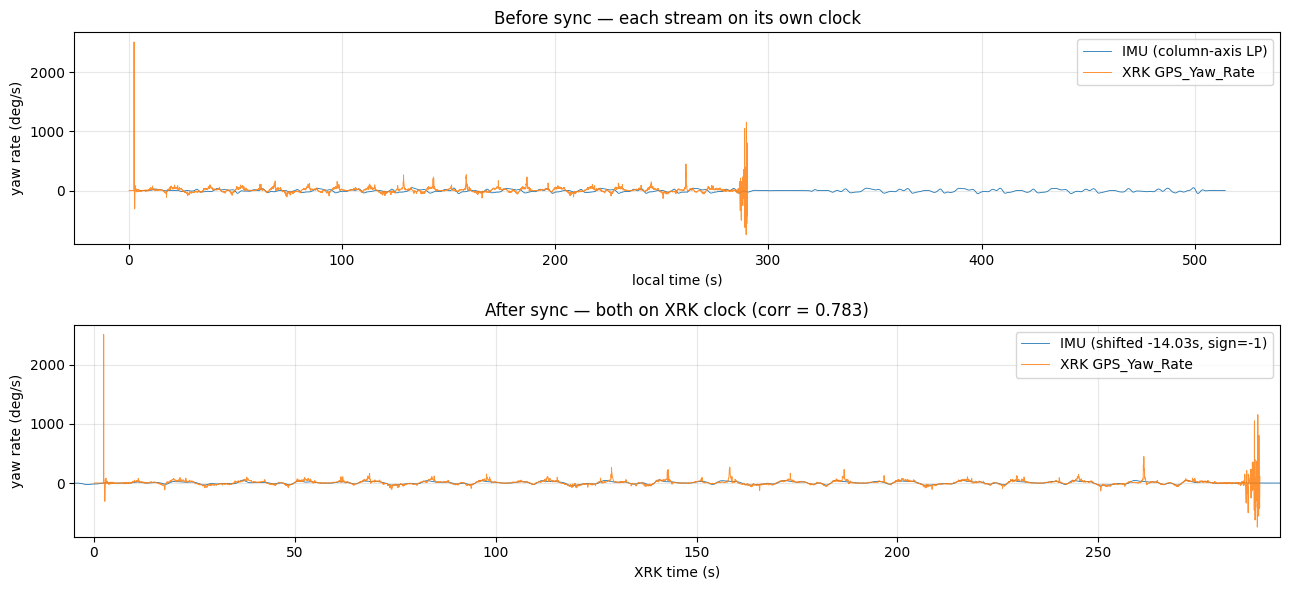

In [4]:
t_imu, yaw_imu, _, _ = chassis_yaw_from_imu(stream)
t_xrk, yaw_xrk = chassis_yaw_from_xrk(log)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharey=True)

axes[0].plot(t_imu, np.rad2deg(yaw_imu), lw=0.6, label="IMU (column-axis LP)")
axes[0].plot(t_xrk, np.rad2deg(yaw_xrk), lw=0.7, label="XRK GPS_Yaw_Rate", alpha=0.85)
axes[0].set_title("Before sync — each stream on its own clock")
axes[0].set_xlabel("local time (s)")
axes[0].set_ylabel("yaw rate (deg/s)")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].plot(t_imu + sync.offset_imu_to_xrk_s,
             sync.sign * np.rad2deg(yaw_imu), lw=0.6,
             label=f"IMU (shifted {sync.offset_imu_to_xrk_s:+.2f}s, "
                   f"sign={sync.sign})")
axes[1].plot(t_xrk, np.rad2deg(yaw_xrk), lw=0.7,
             label="XRK GPS_Yaw_Rate", alpha=0.85)
axes[1].set_xlim(t_xrk[0] - 5, t_xrk[-1] + 5)
axes[1].set_title(f"After sync — both on XRK clock (corr = {sync.corr_peak:.3f})")
axes[1].set_xlabel("XRK time (s)")
axes[1].set_ylabel("yaw rate (deg/s)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


## 5. Body-frame geometry

The wheel-cam IMU sees both steering (wheel rotating relative to chassis) and
chassis yaw (kart turning around vertical axis). The relationship is:

$$\omega_{\text{along column}} = \omega_{\text{steering}} + k \cdot \omega_{\text{chassis yaw}}$$

where:

- **Column axis** in body frame: principal eigenvector of the gyro covariance
  matrix (PCA). Detects the wheel's rotation axis automatically — works for
  any wheel-cam orientation.
- **`k = |column · world_up|`**: the cosine of the column tilt. Computed from
  the recording's own gravity vector (averaged across quiet-rate samples).
  This is geometry, not regression — OLS would underestimate `k` because
  GPS_Yaw_Rate has measurement noise (errors-in-variables attenuation).

In [5]:
# Show the geometry: column axis and gravity in body frame
mag = np.linalg.norm(stream.gyro, axis=1)
quiet = mag < np.deg2rad(2.0)
g_body = stream.accel[quiet].mean(axis=0)
world_up = -g_body / np.linalg.norm(g_body)

print("Body frame:")
print(f"  column axis:  ({sync.column_axis[0]:+.3f}, "
      f"{sync.column_axis[1]:+.3f}, {sync.column_axis[2]:+.3f})")
print(f"  world up:     ({world_up[0]:+.3f}, "
      f"{world_up[1]:+.3f}, {world_up[2]:+.3f})")
print(f"  |g_body|:     {np.linalg.norm(g_body):.3f} m/s²  (gravity ≈ 9.807)")
print()
print(f"  k = |col · up| = {sync.column_tilt_factor:.4f}")
print(f"  → column tilt = {sync.column_tilt_deg:.1f}° from vertical")
print()
print("Steering recovery:")
print("  ω_steer = sign · (gyro · col_axis) − k · GPS_Yaw_Rate")

Body frame:
  column axis:  (-0.315, +0.030, +0.949)
  world up:     (+0.857, -0.035, -0.514)
  |g_body|:     9.607 m/s²  (gravity ≈ 9.807)

  k = |col · up| = 0.7588
  → column tilt = 40.6° from vertical

Steering recovery:
  ω_steer = sign · (gyro · col_axis) − k · GPS_Yaw_Rate



## 6. Lap detection

The XRK's beacon-crossing markers are unreliable in practice — they can fire
once or twice for a whole session, fusing many physical laps into one. We
detect laps from the GPS track instead: a lap is complete when the kart
returns within 25 m of its starting position after having left.

In [6]:
gps_laps = detect_laps_from_gps(log)
xrk_durations = [(e - s) / 1000.0 for s, e in zip(
    log.laps["start_time"].to_pylist(),
    log.laps["end_time"].to_pylist(),
)]

print(f"XRK beacon detection: {len(xrk_durations)} laps")
for i, d in enumerate(xrk_durations):
    flag = "  ← unrealistic" if d > 120 else ""
    print(f"  lap {i}: {d:6.2f} s{flag}")

print()
print(f"GPS return-to-start detection: {len(gps_laps)} laps")
for i, (s, e) in enumerate(gps_laps):
    print(f"  lap {i}: {s:7.2f} .. {e:7.2f} s   ({e - s:5.2f} s)")

XRK beacon detection: 2 laps
  lap 0:  57.70 s
  lap 1: 232.27 s  ← unrealistic

GPS return-to-start detection: 6 laps
  lap 0:    2.49 ..   56.57 s   (54.08 s)
  lap 1:   56.57 ..  101.13 s   (44.56 s)
  lap 2:  101.13 ..  145.45 s   (44.32 s)
  lap 3:  145.45 ..  190.09 s   (44.64 s)
  lap 4:  190.09 ..  233.53 s   (43.44 s)
  lap 5:  233.53 ..  283.01 s   (49.48 s)



## 7. Per-lap plots

For each detected lap, render the 4-panel summary:

- **Steering angle** (deg) — from the IMU, after chassis-yaw subtraction
- **Kart yaw rate** (deg/s) — from XRK `GPS_Yaw_Rate`
- **GPS speed** (km/h) — from XRK `GPS Speed` (m/s × 3.6)
- **GPS track** — lat/lon, colored by speed

A clean kart steering trace should return near 0° on straights and flick
to ±30–60° at corner entry/exit.

In [7]:
lap_windows, source = choose_lap_windows(sync, force_source="auto")
print(f"Using lap source: {source}  ({len(lap_windows)} laps)")
print()

laps_data = []
for i, window in enumerate(lap_windows):
    lap = extract_lap(stream, sync, window, lap_index=i)
    laps_data.append(lap)
    s = lap_summary(lap)
    print(f"  lap {i}: {s['duration_s']:6.2f}s   "
          f"peak steer ±{s['peak_steer_deg']:>4.0f}°   "
          f"peak yaw rate ±{s.get('peak_yaw_rate_dps', float('nan')):>4.0f}°/s   "
          f"peak speed {s.get('peak_speed_kmh', float('nan')):>5.1f} km/h")

Using lap source: gps  (6 laps)

  lap 0:  54.08s   peak steer ±  63°   peak yaw rate ± 309°/s   peak speed  91.4 km/h
  lap 1:  44.56s   peak steer ±  43°   peak yaw rate ± 161°/s   peak speed 107.1 km/h
  lap 2:  44.32s   peak steer ±  74°   peak yaw rate ± 263°/s   peak speed 108.6 km/h
  lap 3:  44.64s   peak steer ±  57°   peak yaw rate ± 267°/s   peak speed 108.6 km/h
  lap 4:  43.44s   peak steer ±  41°   peak yaw rate ± 125°/s   peak speed 106.9 km/h
  lap 5:  49.48s   peak steer ±  54°   peak yaw rate ± 381°/s   peak speed 108.5 km/h


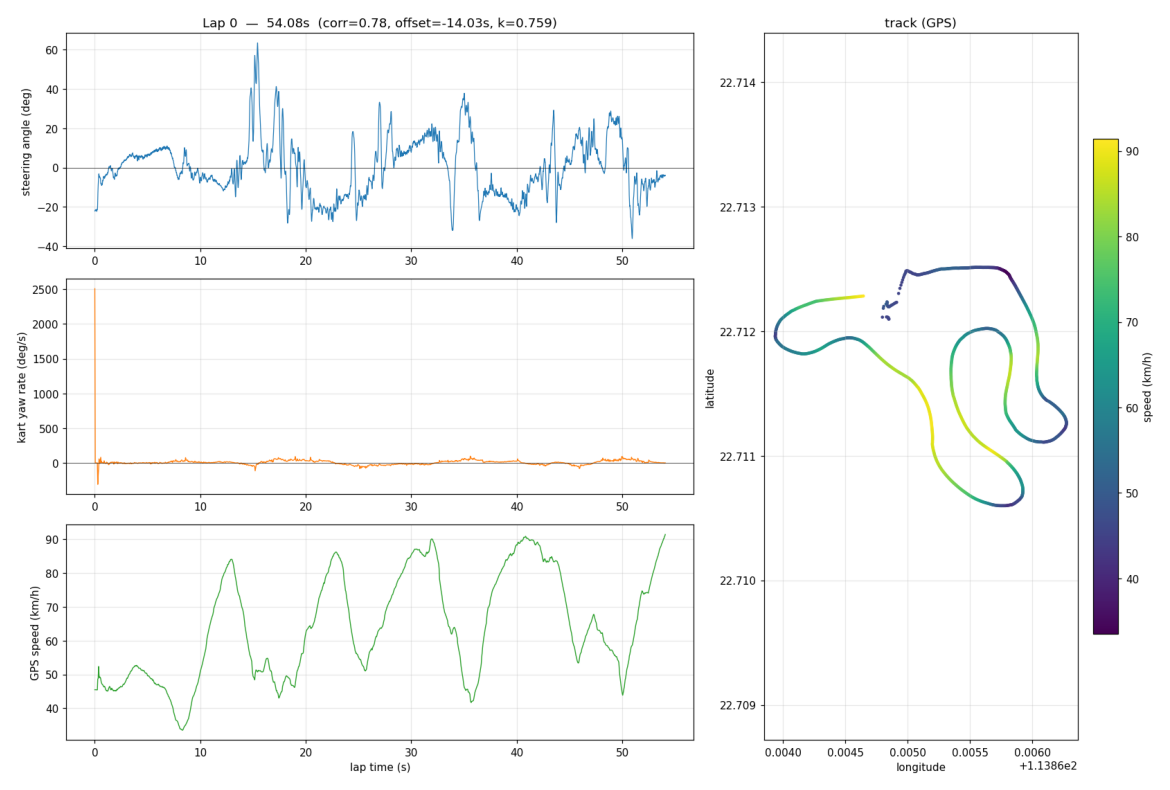

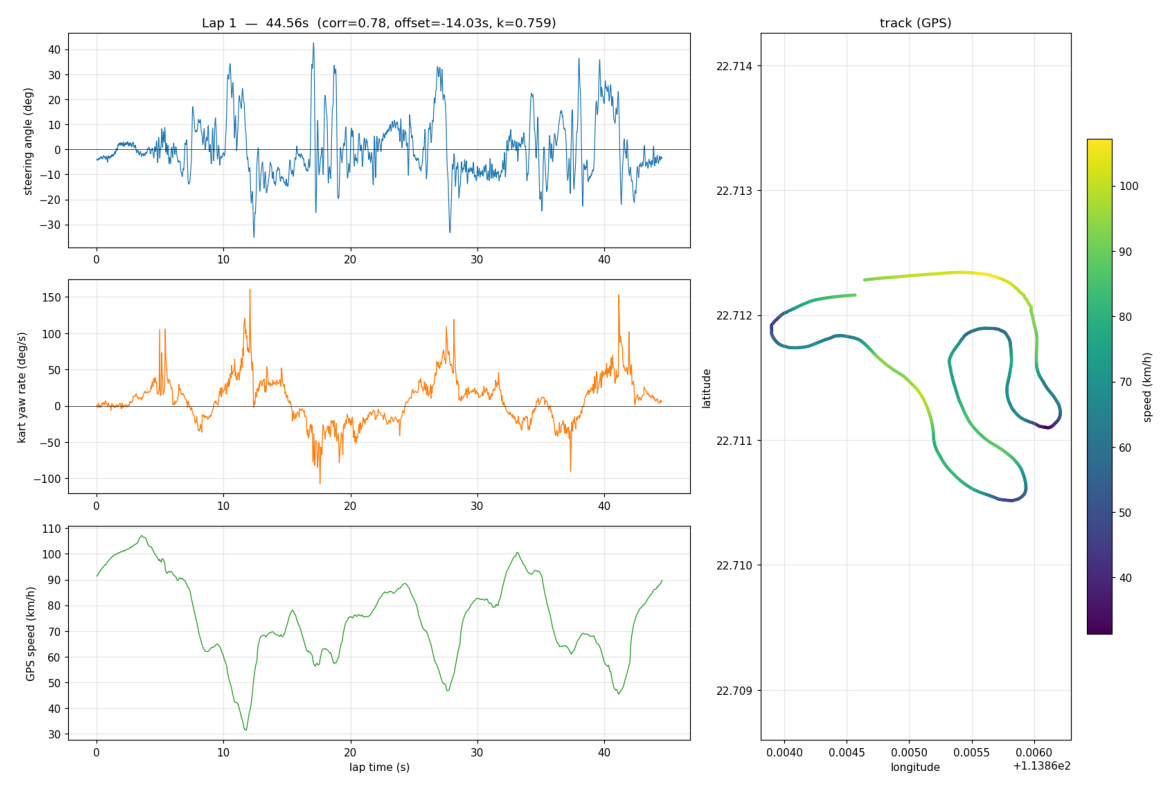

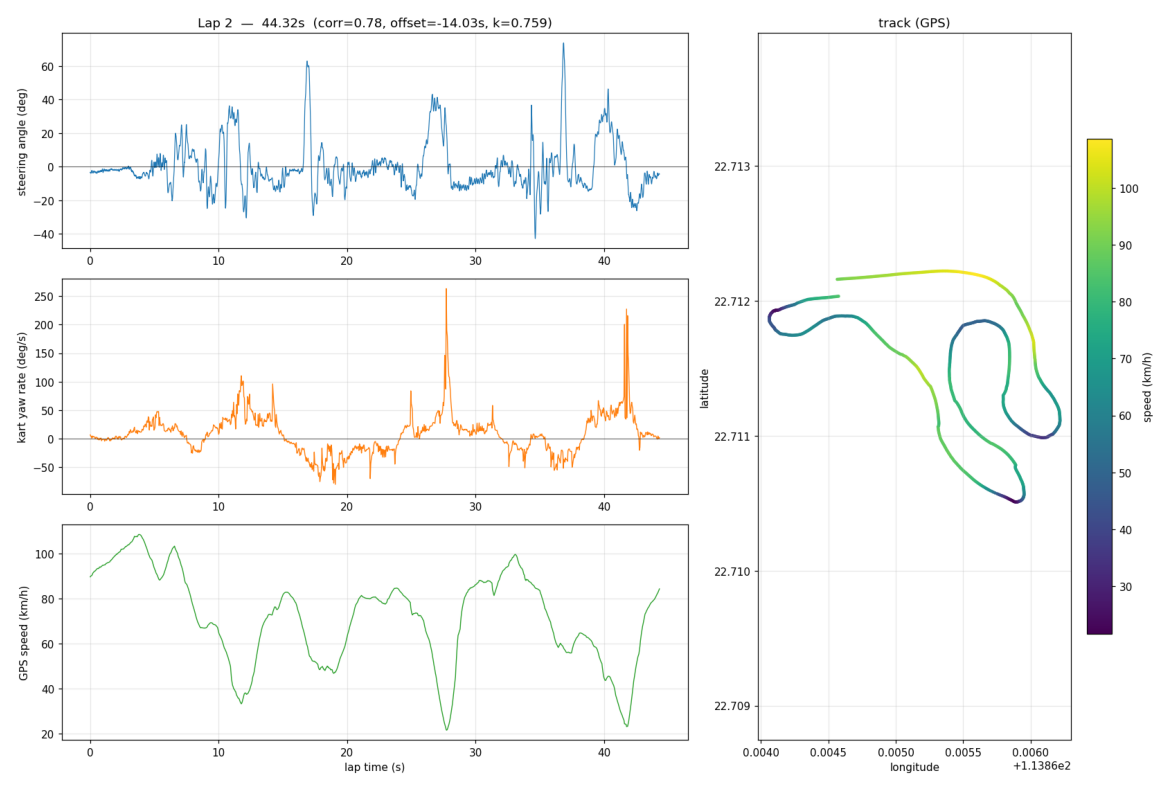

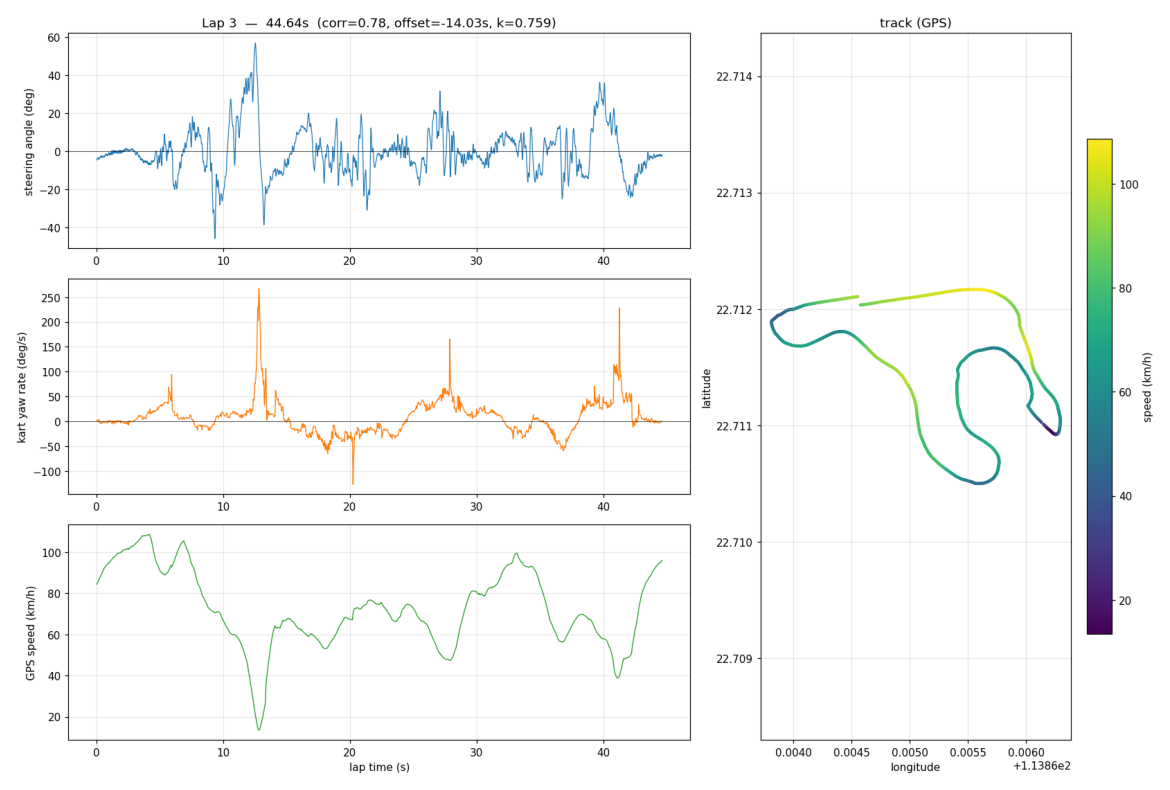

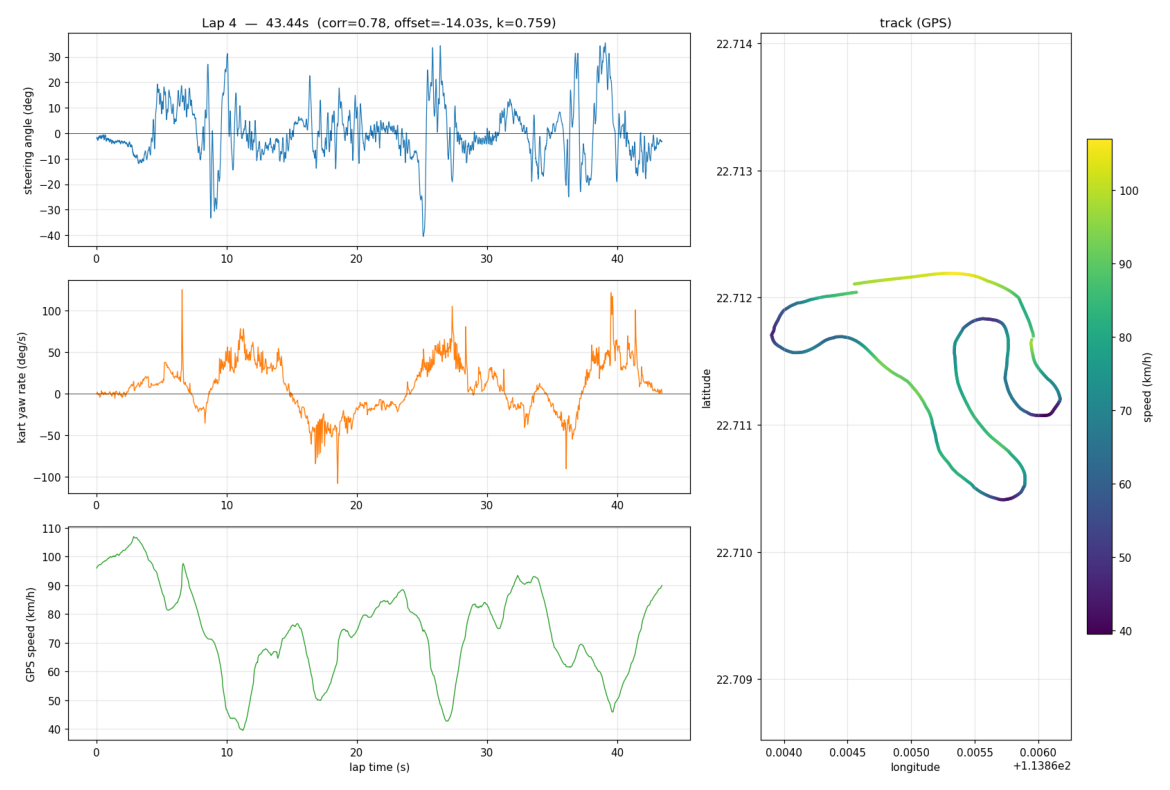

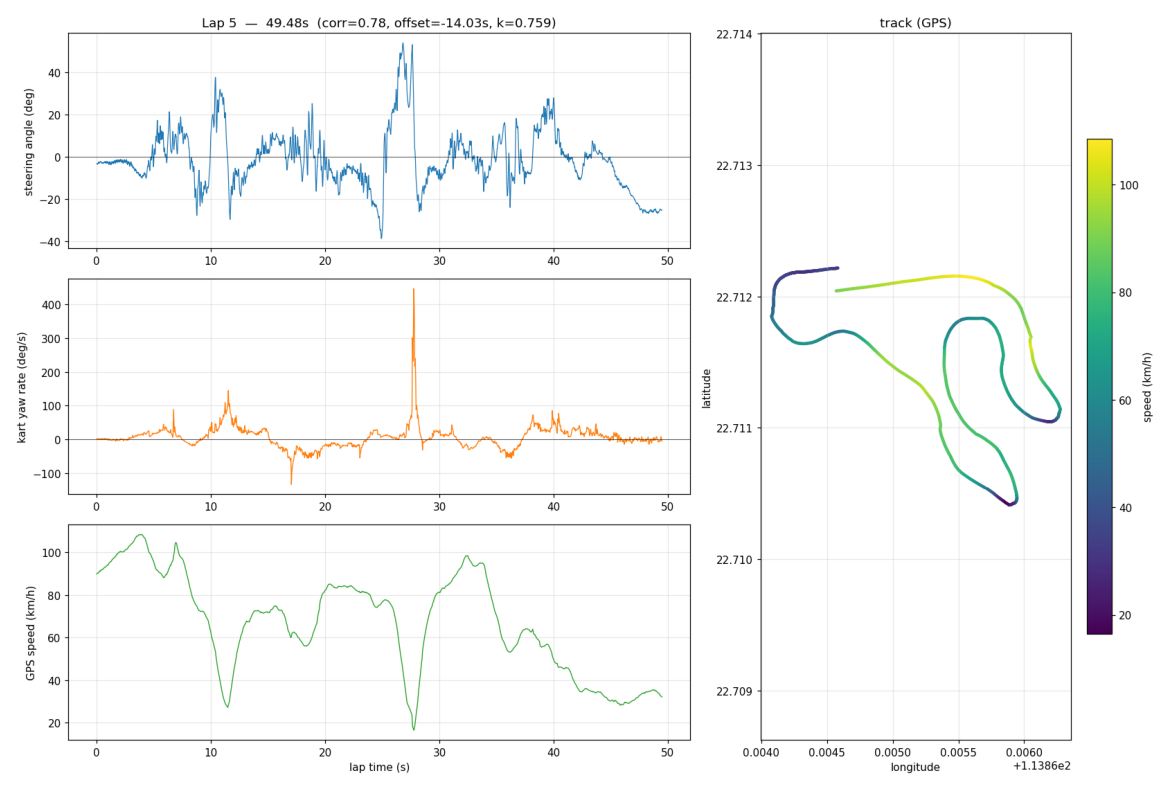

In [8]:
# Render each lap as a 4-panel figure inline.
# (Internally writes a PNG; we re-display it here for inline view.)
import tempfile
import matplotlib.image as mpimg

for lap in laps_data:
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
        out_path = Path(f.name)
    plot_lap(lap, out_path,
             title=f"corr={sync.corr_peak:.2f}, "
                   f"offset={sync.offset_imu_to_xrk_s:+.2f}s, "
                   f"k={sync.column_tilt_factor:.3f}")
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.imshow(mpimg.imread(out_path))
    ax.axis("off")
    plt.show()
    out_path.unlink()


## 8. Summary table

One row per lap, ready for further analysis or export.

In [9]:
rows = []
for lap in laps_data:
    s = lap_summary(lap)
    rows.append({
        "lap": lap.lap_index,
        "duration_s": round(s["duration_s"], 2),
        "peak_steer_deg": round(s["peak_steer_deg"], 1),
        "peak_yaw_rate_dps": round(s.get("peak_yaw_rate_dps", float("nan")), 0),
        "peak_speed_kmh": round(s.get("peak_speed_kmh", float("nan")), 1),
        "mean_speed_kmh": round(s.get("mean_speed_kmh", float("nan")), 1),
    })

df = pd.DataFrame(rows).set_index("lap")
df

,duration_s,peak_steer_deg,peak_yaw_rate_dps,peak_speed_kmh,mean_speed_kmh
lap,,,,,
0,54.08,63.4,309.0,91.4,64.2
1,44.56,42.5,161.0,107.1,75.0
2,44.32,73.9,263.0,108.6,71.6
3,44.64,56.9,267.0,108.6,72.4
4,43.44,40.5,125.0,106.9,74.3
5,49.48,54.1,381.0,108.5,66.8


In [10]:
# Identify the fastest lap and show its plot again for emphasis
fastest = df["duration_s"].idxmin()
print(f"Fastest lap: {fastest}  ({df.loc[fastest, 'duration_s']} s)")
print(f"  peak steer:     ±{df.loc[fastest, 'peak_steer_deg']}°")
print(f"  peak yaw rate:  ±{df.loc[fastest, 'peak_yaw_rate_dps']}°/s")
print(f"  peak speed:     {df.loc[fastest, 'peak_speed_kmh']} km/h")

Fastest lap: 4  (43.44 s)
  peak steer:     ±40.5°
  peak yaw rate:  ±125.0°/s
  peak speed:     106.9 km/h



## 9. What we learned

Notes from running this on the May 11 XTreme session:

- **Insta360 Go 3S IMU rate is 1 kHz**, not the ~200 Hz the docs imply. Great
  for jerk calculations.
- **Wall-clock-based sync doesn't work.** Cameras and loggers drift
  independently. Cross-correlation of chassis-yaw signals is reliable.
- **MyChron beacon lap detection is unreliable.** GPS return-to-start is more
  dependable in practice.
- **`GPS Speed` in XRK is m/s, not km/h.** Always check units.
- **Naive integration leaks chassis yaw at corner frequencies.** A simple
  high-pass filter can't separate steering from chassis yaw because both live
  in the same band. You have to actually *subtract* the GPS yaw rate scaled
  by the geometric tilt factor.
- **For tilted wheel mounts, PCA finds the column axis in body frame
  automatically.** No need to know the mount orientation a priori.

The same notebook should work on any wheel-cam-plus-MyChron session — point
the paths at the top at different files and re-run.